<a href="https://colab.research.google.com/github/rumijay/Data-Science-2025/blob/main/Rumi_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is a  machine learning algorithm that acts like a visual flowchart to make decisions or predictions

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of a decision tree is the length of the longest path from the root node to a leaf node, representing the maximum number of consecutive decisions or splits

**Task4:**

How are BART models similar and different from a decision tree?

Similarities:

Both use trees to make predictions, split data based on predictor variables, and can model nonlinear relationships

Differences:

A decision tree is just one tree, A BART mod is a sum of many small trees, BART is Bayesian, meaning it gives uncertainty (posterior distributions), not just one prediction, BART tends to be more accurate

**Task5**:

Why would we use a BART model instead of a decision tree?

We use BART because it avoids overfitting better than a single tree, it captures complex relationships automatically, provides uncertainty estimates (credible intervals), usually has better predictive performance

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [3]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [21]:
!pip install pymc-bart

In [ ]:
import pymc as pm
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import arviz as az

X = penguins[["flipper_length","bill_depth","bill_length"]]
y = penguins["body_mass"]

with pm.Model() as model:

    mu = pmb.BART("mu", X.values, y.values)

    sigma = pm.HalfNormal("sigma", 1000)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y.values)

    trace = pm.sample(1000, tune=1000)

    ppc = pm.sample_posterior_predictive(trace)

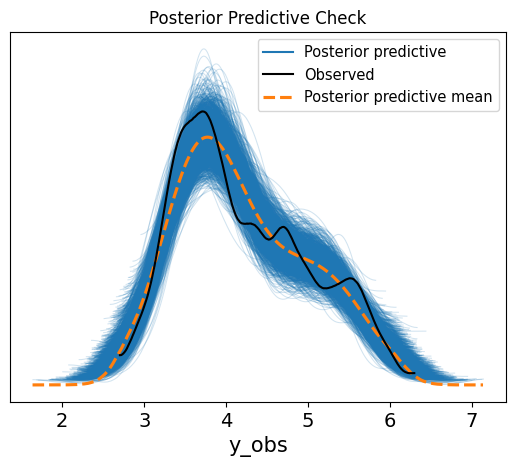

In [37]:
pm.plot_ppc(ppc)
plt.title("Posterior Predictive Check")
plt.show()

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

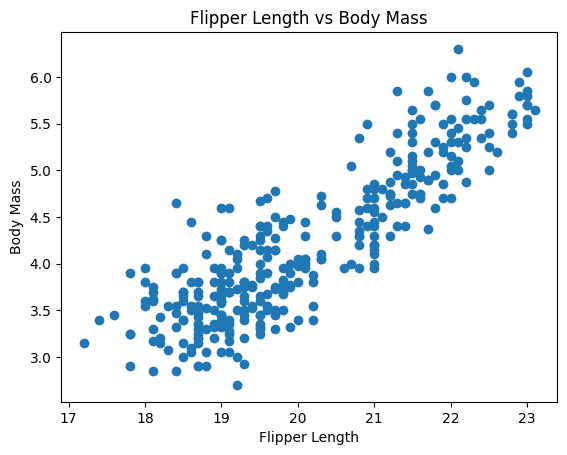

In [29]:
import matplotlib.pyplot as plt

plt.scatter(X["flipper_length"], y)
plt.xlabel("Flipper Length")
plt.ylabel("Body Mass")
plt.title("Flipper Length vs Body Mass")
plt.show()

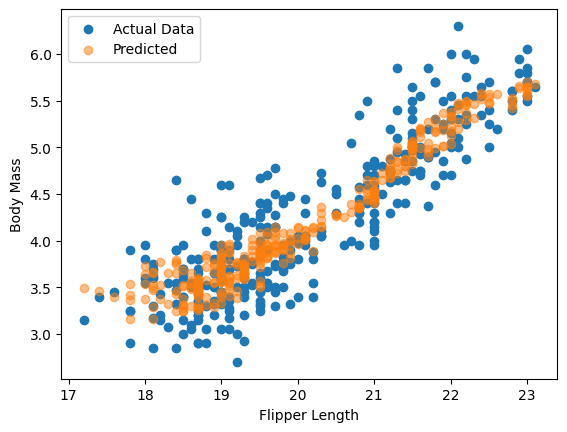

In [32]:
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=("chain", "draw")).values

plt.scatter(X["flipper_length"], y, label="Actual Data")
plt.scatter(X["flipper_length"], y_pred, label="Predicted", alpha=0.5)

plt.xlabel("Flipper Length")
plt.ylabel("Body Mass")
plt.legend()

plt.show()

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

The plot shows a clear positive trend, and the predicted points mostly follow the same pattern as the actual data, so the model is doing a pretty good job. It’s not perfect though because there’s still some spread in the real data that the model doesn’t fully capture.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

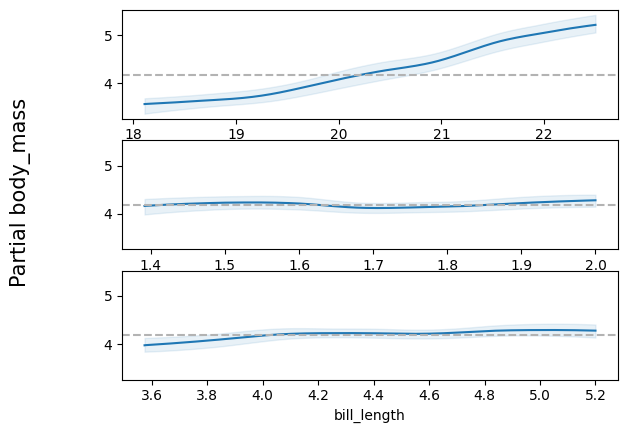

In [38]:
import pymc_bart as pmb
import matplotlib.pyplot as plt

pmb.plot_pdp( mu,   X=X,   Y=y,   grid="long",   var_discrete=[]
)

plt.show()

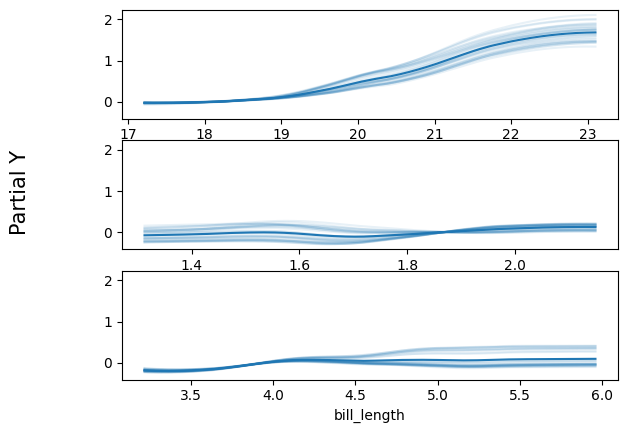

In [39]:
pmb.plot_ice( mu, X=X)

plt.show()

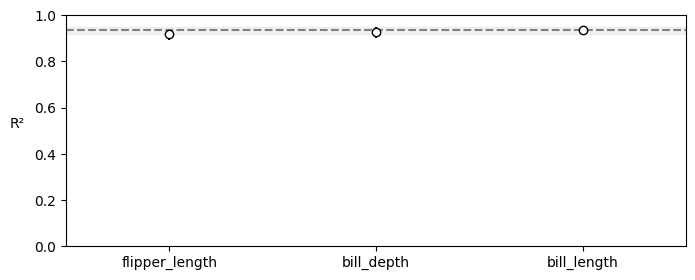

In [49]:
vi_results = pmb.compute_variable_importance(trace, mu, X, y)
pmb.plot_variable_importance(vi_results, labels=X.columns.tolist())
plt.show() #gemini helped

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Flipper length is the most important variable because the variable importance plot shows it has the biggest impact, and its PDP has a strong upward trend with body mass. bill length has a smaller positive effect, while bill depth doesn’t really change body mass much since its PDP is pretty flat. The ICE plots aren’t all parallel, which shows there are sum interactions between variables, meaning the effect of one variable depends on the others.